# **Oil Prices 2024–2026 - Exploratory data analysis and time series diagnostics**

(Given the copies of plots in the markdown, if it's not visible in git or editors)

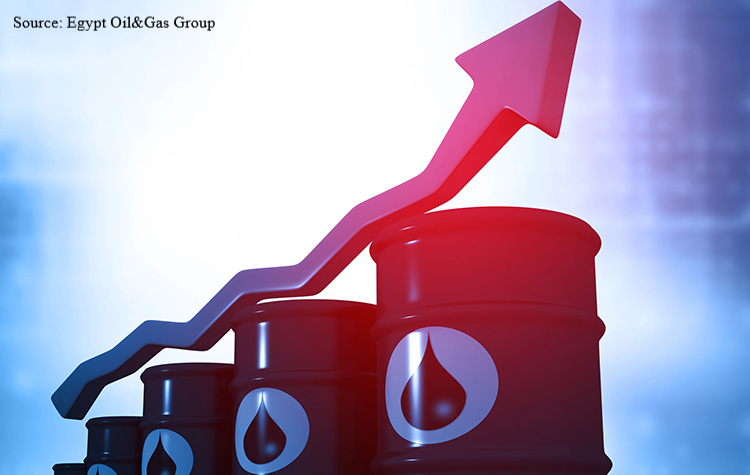

I am going to start by checking the data quality and plot the oil prices to understand the data better. Then I will transform it into first differences and log returns, test them if stationary, and do autocorelation in both returns and its squares. Finally, I will check how the data is clustered to see which baseline models are better to use on it.

## **Imports**

In [2]:
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from scipy.stats import jarque_bera, skew, kurtosis
import scipy.stats as stats

from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings("ignore")

## **Load the data**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/oil_prices_2426.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

y = df["price (dollars)"].astype(float).asfreq("D")
log_y = np.log(y)
dy = y.diff()
r = log_y.diff()

## **Inspecting the data**

In [4]:
print("Start:", y.index.min())
print("End:", y.index.max())
print("Observations:", len(y))
print("Missing values:", int(y.isna().sum()))
print("Duplicate timestamps:", int(y.index.duplicated().sum()))
print("Inferred freq:", pd.infer_freq(y.index))

pd.Series({
    "mean": y.mean(),
    "std": y.std(),
    "min": y.min(),
    "max": y.max()
}).to_frame("level_stats")

Start: 2024-09-21 00:00:00
End: 2026-02-02 00:00:00
Observations: 500
Missing values: 0
Duplicate timestamps: 0
Inferred freq: D


,level_stats
mean,75.873980
std,42.912398
min,16.480000
max,158.780000


The data looks clean. There are 500 observations from 21st of September, 2024 to 2nd of Febraury, 2026, with no missing values and no duplicate timestamps. Oil prices are ranging from ~16 to ~159 dollars with a mean around ~76 and with a standard deviation of ~43. The series swings a lot, which shows it's high volitility.

## **Oil price level**

In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y.index, y=y.values, name="Price", line=dict(width=2)))
fig.update_layout(template="plotly_white",
                  title=dict(text="Oil Price (Level)", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14),
                  margin=dict(l=60, r=30, t=70, b=60))
fig.show()

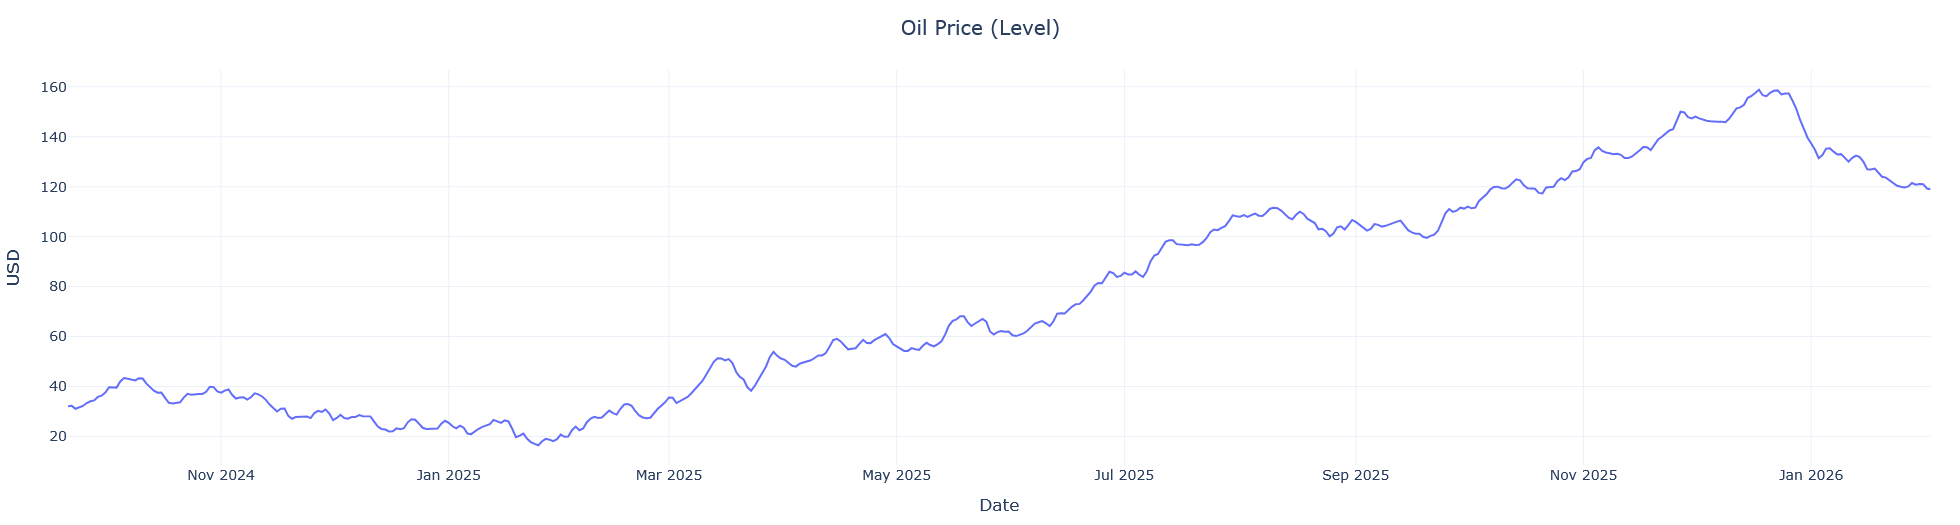

The plot shows a lot of drift in the long run with a lot of up and downs. It shows that the raw series is not stationary. So, to work with ARMA, I will stationary transform of the series and reconstruct later in the forcast.

## **Checking the returns and rolling volitility**

In [6]:
vol30 = r.rolling(30).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=r.index, y=r.values, name="Log returns", line=dict(width=1)))
fig.add_trace(go.Scatter(x=vol30.index, y=vol30.values, name="30D rolling vol", line=dict(width=2)))

fig.update_layout(template="plotly_white",
                  title=dict(text="Log Returns + 30D Rolling Volatility", x=0.5),
                  xaxis_title="Date", yaxis_title="Return / Vol",
                  font=dict(size=14),
                  margin=dict(l=60, r=30, t=70, b=60))
fig.show()

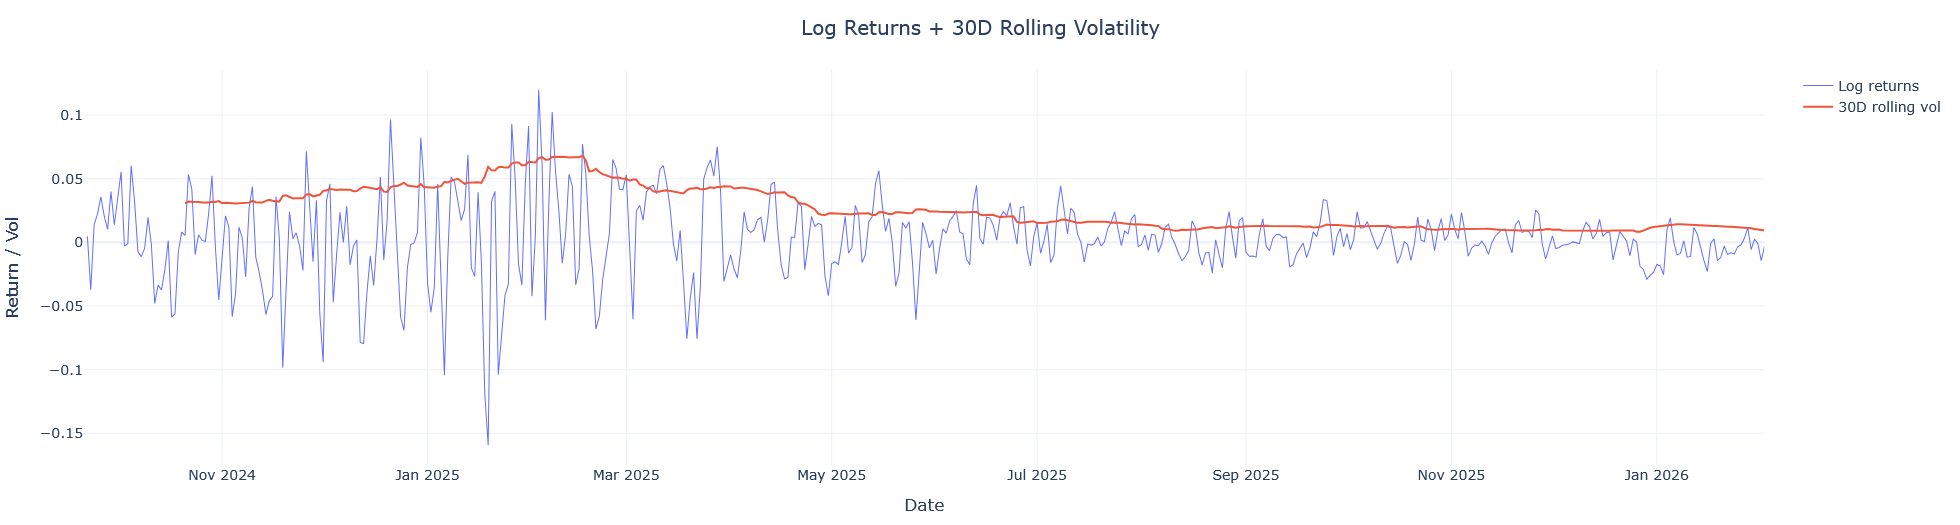

The log returns stays around zero like expected, but volitility is not constant, where it's high at the starts, but drops down as it goes in the later. It shows the volitility clustering, where the bigger swings group together. So, simple models that assume constant variance will usually give a bit narrower uncertatinity bands.

# **Stationary tests (ADF and KPSS)**

In [13]:
def stationarity(series):
    """
    Return ADF and KPSS p-values to quickly assess whether a time series looks stationary
    """
    s = series.dropna()
    return pd.Series({
        "ADF p": adfuller(s, autolag="AIC")[1],
        "KPSS p": kpss(s, nlags="auto")[1],
    })

out = pd.concat([
    stationarity(y).rename("Level"),
    stationarity(dy).rename("1st Difference"),
    stationarity(r).rename("Log Returns")
], axis=1)

out

,Level,1st Difference,Log Returns
ADF p,0.882674,0.000165,2.754899e-08
KPSS p,0.010000,0.100000,1.000000e-01


In the raw series, the ADF has high p-value means it fails to reject the unit root hypothesis and KPSS rejects stationarity hypothesis since the p-value is low. Both says that the raw series is non-stationary. But for the first difference and log returns, ADF strongly rejected a unit root and KPSS does not rejected the stationarity hypothesis. So, we can fit models like ARMA on returns rather than the raw series.

## **ACF and PACF plots**

In [23]:
def corr_plot(series, kind="acf", nlags=40, title=""):
    """
    Plot the ACF or PACF bars with 95% confidence bounds for quick autocorrelation diagnostics.
    """
    s = series.dropna().values
    vals = acf(s, nlags=nlags) if kind == "acf" else pacf(s, nlags=nlags)
    lags = np.arange(len(vals))
    conf = 1.96 / np.sqrt(len(s))

    fig = go.Figure()
    fig.add_trace(go.Bar(x=lags, y=vals, name=kind.upper()))
    fig.add_trace(go.Scatter(x=lags, y=[conf]*len(lags), mode="lines",
                             line=dict(dash="dash", width=2), name="95% bound"))
    fig.add_trace(go.Scatter(x=lags, y=[-conf]*len(lags), mode="lines",
                             line=dict(dash="dash", width=2), showlegend=False))

    fig.update_layout(template="plotly_white",
                      title=dict(text=title, x=0.5),
                      xaxis_title="Lag",
                      yaxis_title=kind.upper(),
                      font=dict(size=14),
                      margin=dict(l=60, r=30, t=70, b=60))
    fig.show()

corr_plot(r, "acf", 40, "ACF of Log Returns")
corr_plot(r, "pacf", 40, "PACF of Log Returns")

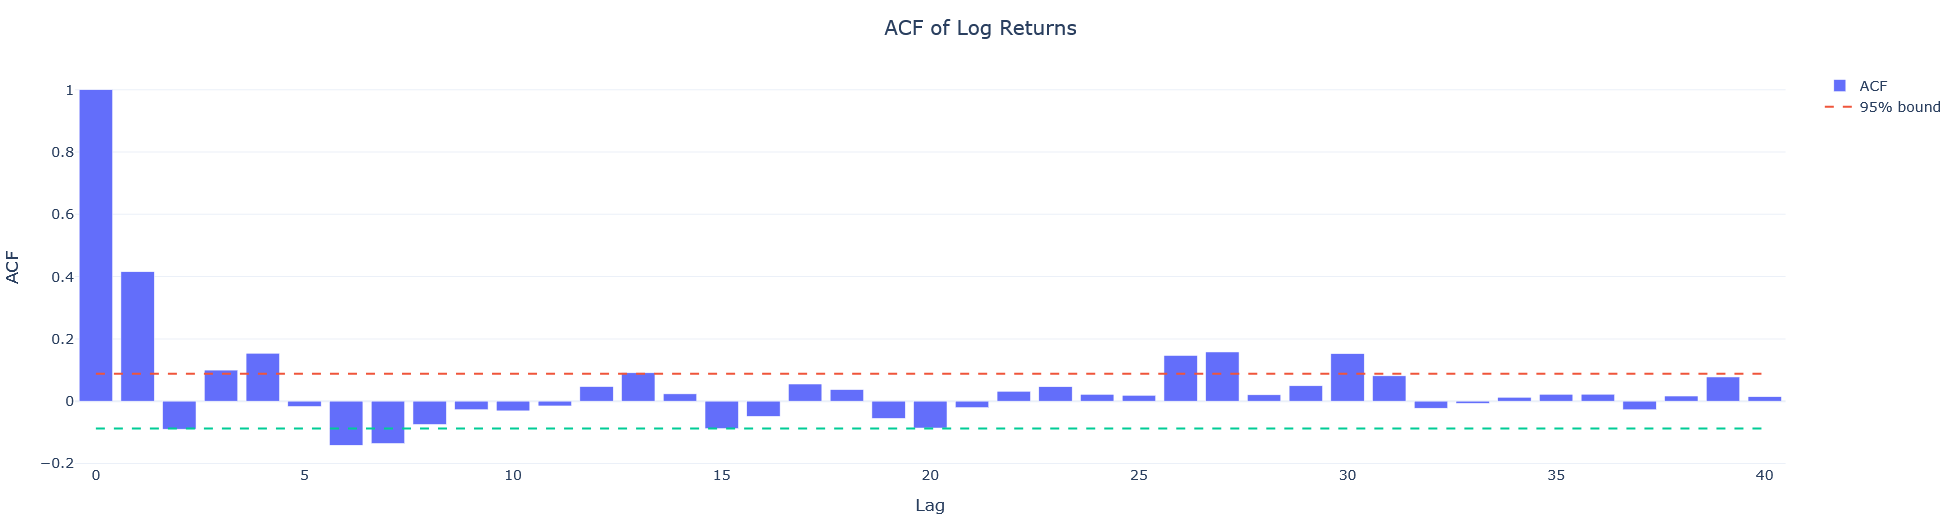

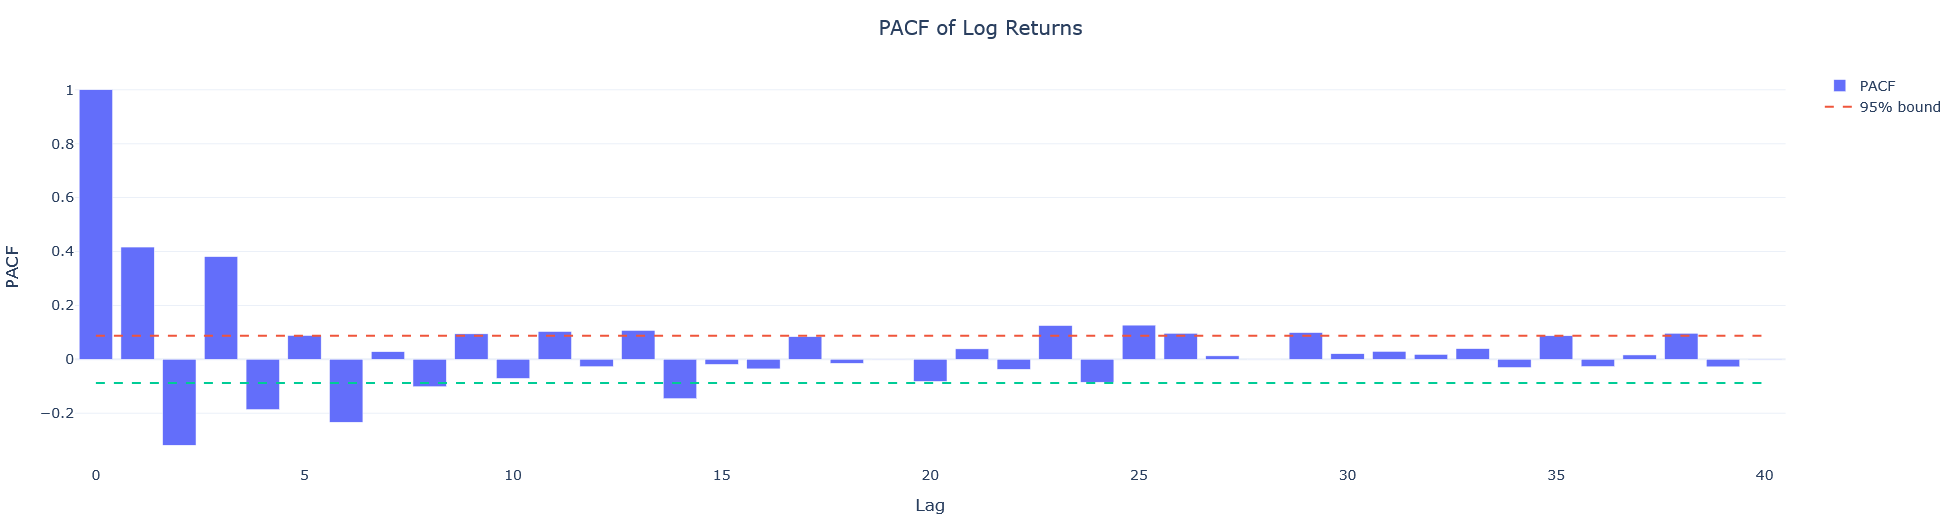

The returns are not entirely white noise, there are lags beyond the threshold. So, ARMA like models are good for this series.

## **Checking how the returns are distributed**

In [15]:
fig = px.histogram(r.dropna(), nbins=60, histnorm="probability density")
fig.update_layout(template="plotly_white",
                  title=dict(text="Distribution of Log Returns", x=0.5),
                  xaxis_title="Return", yaxis_title="Density",
                  font=dict(size=14),
                  margin=dict(l=60, r=30, t=70, b=60))
fig.show()

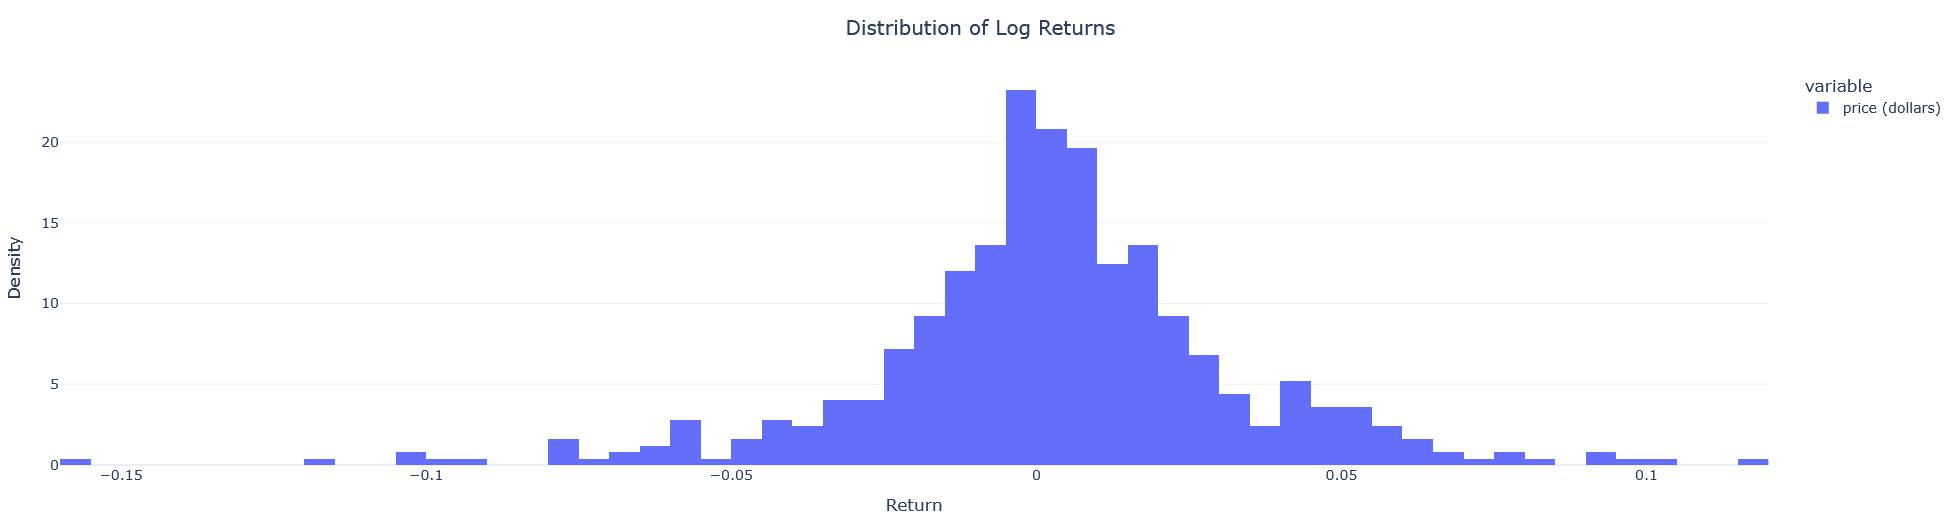

The histogram is centred close to zero, but it’s not perfectly symmetric and it has fatter tails than a normal distribution.

### **Checking the Jarque-Bera value**

The Jarque-Bera (JB) test is a goodness-of-fit statistic used to determine whether sample data follows a normal distribution based on skewness and kurtosis.

In [16]:
jb_stat, jb_p = jarque_bera(r.dropna())
pd.Series({
    "JB p-value": jb_p,
    "skew": float(skew(r.dropna())),
    "excess kurtosis": float(kurtosis(r.dropna()))
})

,0
JB p-value,9.474829e-50
skew,-4.245705e-01
excess kurtosis,3.183899e+00


From the JB test, the p-value is almost zero indicating that there is a strong rejection of normality. Skew is slightly negative, showing more negative returns than positive. The kurtosis value is ~3.18, which shows that the distribution has more bigger tails than a normal one.

## **Volitility clustering**

In [17]:
corr_plot(r.dropna()**2, "acf", 40, "ACF of Squared Returns")

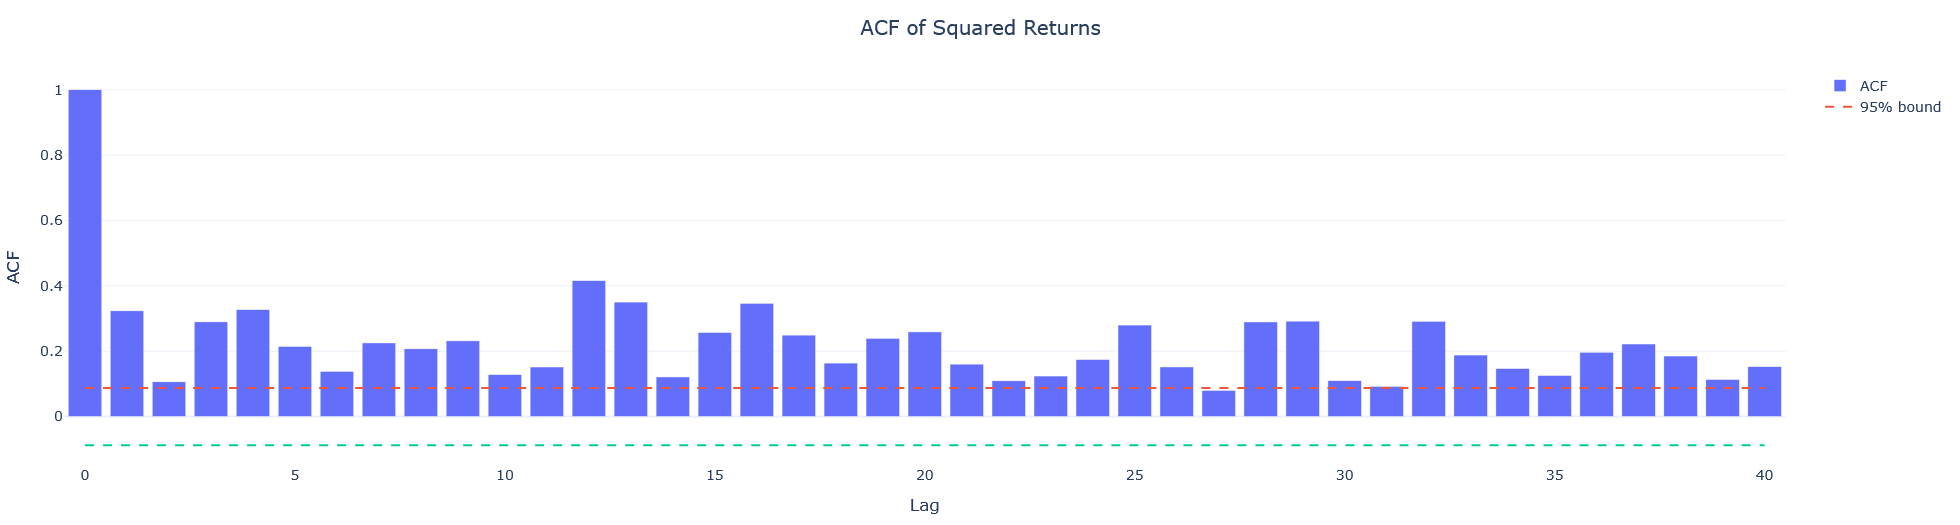

## **ARCH test**

The ARCH (Autoregressive Conditional Heteroscedasticity) test, developed by Robert Engle, is a statistical method used to detect and model time-varying volatility in financial time series data.

In [18]:
arch_stat, arch_p, _, _ = het_arch(r.dropna())
pd.Series({"ARCH p-value": arch_p, "ARCH stat": arch_stat})

,0
ARCH p-value,4.128284e-20
ARCH stat,1.155016e+02


The variance changes over time and those changes are predictable from recent volitility. It makes sense why modelling the mean alone wont be enough for realistic uncertainity bands.

## **Ljung–Box test**

The Ljung–Box test (named for Greta M. Ljung and George E. P. Box) is a type of statistical test of whether any of a group of autocorrelations of a time series are different from zero. Instead of testing randomness at each distinct lag, it tests the "overall" randomness based on a number of lags, and is therefore a portmanteau test.

In [19]:
lb_r = acorr_ljungbox(r.dropna(), lags=[5,10,20,30], return_df=True)
lb_sq = acorr_ljungbox((r.dropna()**2), lags=[5,10,20,30], return_df=True)

lb_r.columns = ["lb_stat", "lb_pvalue"]
lb_sq.columns = ["lb_stat", "lb_pvalue"]

print("Ljung–Box (returns)")
display(lb_r)

print("Ljung–Box (squared returns)")
display(lb_sq)

Ljung–Box (returns)


,lb_stat,lb_pvalue
5,107.854464,1.163589e-21
10,131.120279,2.759552e-23
20,149.875952,6.639001e-22
30,190.638177,2.752010e-25


Ljung–Box (squared returns)


,lb_stat,lb_pvalue
5,177.987557,1.439447e-36
10,271.162145,1.902743e-52
20,649.883098,8.676050e-125
30,846.972145,8.555374e-159


The p-values are almost zero, so, the returns still have autocorrelation structure. The squared returns are highly autocorrelated, which means volitility strongly clusters. But, if I try to build forecast intervals assuming constant variance, they might be wrong.

## **Checking for extremes**

In [20]:
ext = r.dropna().abs().sort_values(ascending=False).head(10).index
tbl = pd.DataFrame({"price": y.loc[ext], "return": r.loc[ext]}).sort_index()
tbl

,price,return
date,,
2024-11-19,28.24,-0.098396
2024-12-01,26.53,-0.094179
2024-12-21,25.66,0.096480
2025-01-06,21.16,-0.104462
2025-01-18,23.08,-0.119515
2025-01-19,19.68,-0.159364
2025-01-22,19.06,-0.104048
2025-01-26,18.09,0.093212
2025-02-03,22.49,0.119842


The bigger swings are piled up early in the sample, like in late 2024 and early 2025. It also aligns from observing the rolling volitility. It's clear why normalitty tests fail. But changing anything would break the realism, so I have to make the models to handle them.

## **Seasonal-Trend Decomposition**

STL (Seasonal-Trend decomposition using Loess) is a robust, versatile method for decomposing time series data into three distinct components: Seasonal (repeating patterns), Trend (long-term progression), and Remainder/Residual (irregular variations).

In [21]:
res = STL(log_y.dropna(), period=7, robust=True).fit()

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=["Trend", "Seasonal", "Residual"])

fig.add_trace(go.Scatter(x=res.trend.index, y=res.trend.values, line=dict(width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=res.seasonal.index, y=res.seasonal.values, line=dict(width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=res.resid.index, y=res.resid.values, line=dict(width=1)), row=3, col=1)

fig.add_hline(y=0, line_dash="dot", line_width=1, row=2, col=1)
fig.add_hline(y=0, line_dash="dot", line_width=1, row=3, col=1)

fig.update_layout(template="plotly_white",
                  title=dict(text="STL Decomposition (log price, period=7)", x=0.5),
                  height=780, showlegend=False,
                  font=dict(size=14),
                  margin=dict(l=60, r=30, t=80, b=60))
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_yaxes(title_text="log(price)", row=1, col=1)
fig.update_yaxes(title_text="seasonal", row=2, col=1)
fig.update_yaxes(title_text="residual", row=3, col=1)

fig.show()

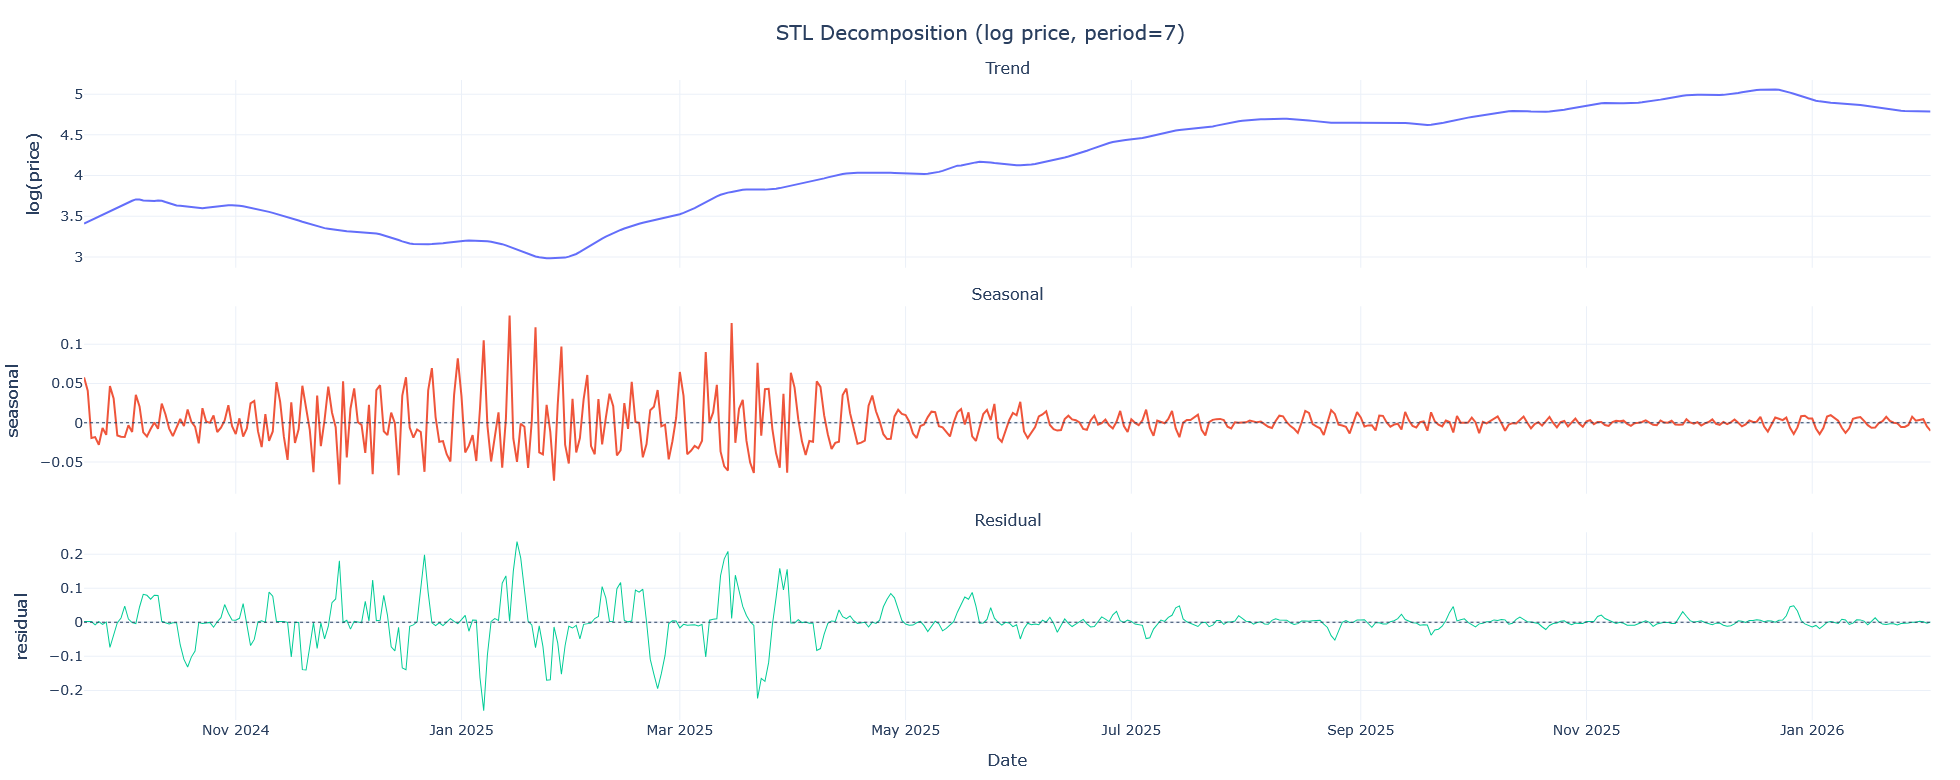

The main focus would be on trend, the short spikes and the time dependant volitility. There's no clean seasonal cycle.

# **Summary**

* The raw oil price series is non-stationary, but the first differences and log returns are stationary. The returns are not normal and there's no constant volitility, which shows the bigger tails and volitility clustering. There is also short-spike dependence in returns, so modelling the mean is not entirely pointless.

* I am going to fit three models. The first one would be ARMA from scratch on a stationary transform as an interpretable baseline. The second would be a delta-LSTM to capture nonlinear patterns while keeping the forecasts stable. Finally, an attempt on a hybrid time series model as the strongest benchmark. I will compare them on the same split using RMSE and pick the best one to deploy(if I have time).